### Retail Store Sales Data - Walmart Store Sales

In [1]:
# Import libraries and load Data
import pandas as pd
df = pd.read_csv(r"E:\Datasets\Walmart.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


#### Q1. What is the total sales across all stores?

In [2]:
total_sales = df['Weekly_Sales'].sum()
print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $6,737,218,987.11


#### Q2. Which store had the highest total sales?

In [3]:
sales_by_store = df.groupby('Store')['Weekly_Sales'].sum()
top_store = sales_by_store.idxmax()
top_sales = sales_by_store.max()
print(f"Total Sales for Store {top_store}: ${top_sales:,.2f}")

Total Sales for Store 20: $301,397,792.46


#### Q3. What is the average weekly sales during holidays vs non-holidays?

In [4]:
holiday_sales = df[df['Holiday_Flag']==1]['Weekly_Sales'].mean()
non_holiday_sales = df[df['Holiday_Flag']==0]['Weekly_Sales'].mean()
print(f"Avg Holiday Weekly Sales: ${holiday_sales:,.2f}")
print(f"Avg Non-Holiday Weekly Sales: ${non_holiday_sales:,.2f}")

Avg Holiday Weekly Sales: $1,122,887.89
Avg Non-Holiday Weekly Sales: $1,041,256.38


#### Q4. What is the trend of sales over time?

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
sales_by_time = df.groupby('Date')['Weekly_Sales'].sum()

C:\Users\hp\AppData\Local\Temp\ipykernel_11612\4018064720.py:1: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  df['Date'] = pd.to_datetime(df['Date'])


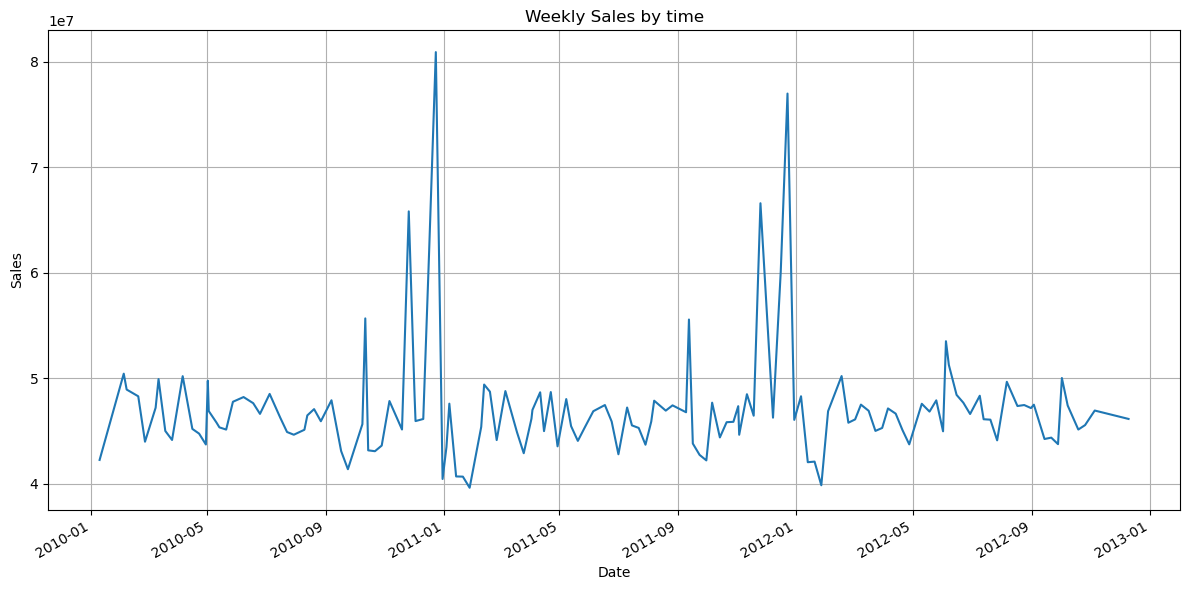

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize = (12,6))
sales_by_time.plot(title = 'Weekly Sales by time')
plt.ylabel('Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

#### Q5. Is there any correlation between Fuel Price and Weekly Sales?

In [7]:
correlation = df[['Fuel_Price', 'Weekly_Sales']].corr().iloc[0,1]
print(f"Corr between FuelPrice and Sales: {correlation:.4f}")

Corr between FuelPrice and Sales: 0.0095


#### Q6. Which stores are affected most during holidays?

In [8]:
holiday_store_sales = df[df['Holiday_Flag']==1].groupby('Store')['Weekly_Sales'].mean()
overall_store_sales = df.groupby('Store')['Weekly_Sales'].mean()
drop_in_sales = (overall_store_sales - holiday_store_sales).sort_values(
    ascending=False)

print("Store with biggest drop in sales during holidays: ")
print(drop_in_sales.head())

Store with biggest drop in sales during holidays: 
Store
37    11375.231958
44     6713.265014
36     5871.362797
38     4221.775287
30     1720.309224
Name: Weekly_Sales, dtype: float64


#### Q7. Does Unemployment rate affect sales?

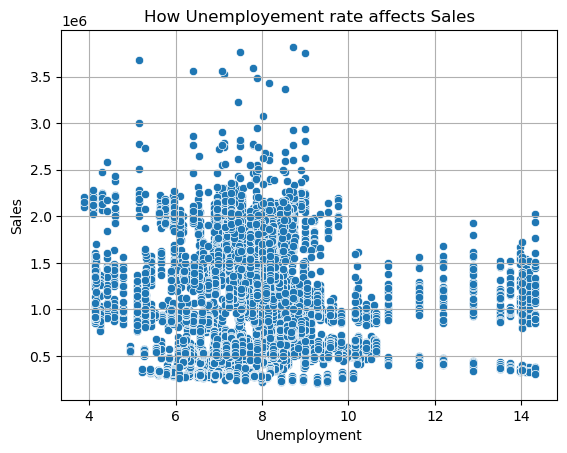

In [9]:
import seaborn as sns
sns.scatterplot(x='Unemployment', y='Weekly_Sales', data=df)
plt.title('How Unemployement rate affects Sales')
plt.ylabel('Sales')
plt.grid(True)
plt.show()